In [1]:
# To run a quarto file, you can use the following command in your terminal:
# quarto render NBA_Analysis.ipynb

import pandas as pd

# Load data
player_df = pd.read_csv("nba_analysis_data.csv")
team_df = pd.read_csv("NBA_Dataset/Team Totals.csv")

# Filter seasons
recent_seasons = [2020, 2021, 2022, 2023, 2024, 2025]
team_df = team_df[team_df['season'].isin(recent_seasons)]

# Use abbreviation instead of full team name
team_df = team_df[['season', 'abbreviation', 'pts']]
team_df = team_df.rename(columns={
    'abbreviation': 'team',
    'pts': 'team_points'
})

# Average shooting efficiency per team
team_eff = player_df.groupby(['season', 'team'])['e_fg_percent'].mean().reset_index()
team_eff = team_eff.rename(columns={'e_fg_percent': 'avg_eFG'})

# Merge (this will now work)
final_df = pd.merge(team_eff, team_df, on=['season', 'team'])

print(final_df.head())

   season team   avg_eFG  team_points
0    2020  ATL  0.495250       7488.0
1    2020  BOS  0.512375       8183.0
2    2020  BRK  0.508647       8048.0
3    2020  CHI  0.532000       6945.0
4    2020  CHO  0.503385       6687.0


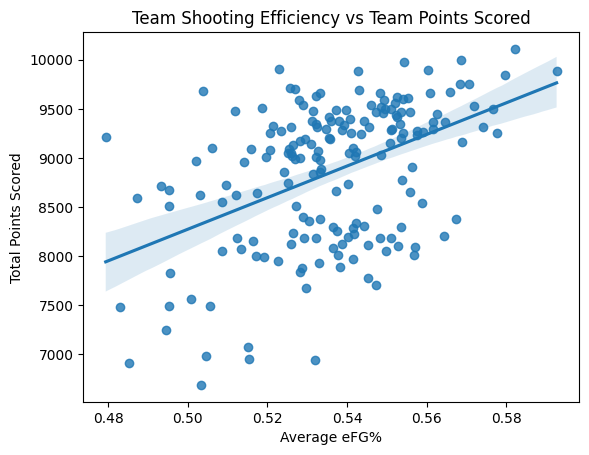

In [2]:
#| label: fig-team-efficiency-points
#| fig-cap: "A scatter plot with a regression line showing the relationship between average eFG% and total points scored by teams in recent NBA seasons."

# Visualization 1: Relationship between team shooting efficiency (eFG%) and scoring output
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(data=final_df, x='avg_eFG', y='team_points')

plt.title("Team Shooting Efficiency vs Team Points Scored")
plt.xlabel("Average eFG%")
plt.ylabel("Total Points Scored")

plt.figure(figsize=(8,5))
plt.close()

This visualization examines the relationship between team shooting efficiency and overall team performance. Shooting efficiency is measured using average effective field goal percentage (eFG%), which accounts for the added value of three-point shots. Team performance is represented by total points scored. A regression line is included to highlight the overall trend. The plot shows a positive relationship, suggesting that teams with higher shooting efficiency tend to score more points, although some variation still exists.

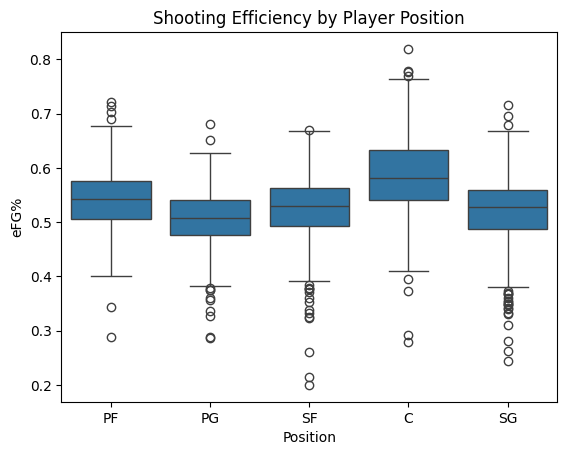

In [3]:
# Visualization 2: Comparison of shooting efficiency across player positions

sns.boxplot(data=player_df, x='pos', y='e_fg_percent')

plt.title("Shooting Efficiency by Player Position")
plt.xlabel("Position")
plt.ylabel("eFG%")

plt.figure(figsize=(8,5))
plt.close()

This visualization compares shooting efficiency across different player positions. Effective field goal percentage (eFG%) is used to measure efficiency, allowing for a more accurate representation of shooting performance. The boxplot shows the distribution of eFG% for each position, including median values and variability. Overall, centers tend to have higher shooting efficiency compared to guards, while guards show slightly lower median values and more variation. This supports the idea that player position plays a role in shooting efficiency.

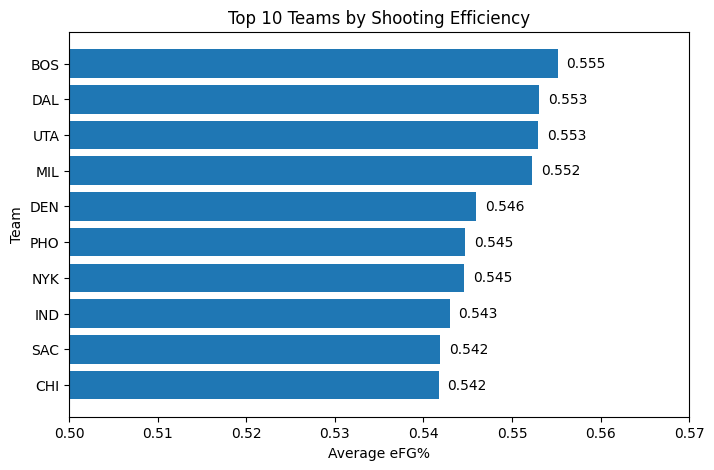

In [4]:
# Visualization 3: Top 10 teams ranked by average shooting efficiency

import matplotlib.pyplot as plt

team_avg = final_df.groupby('team')['avg_eFG'].mean().reset_index()
team_avg = team_avg.sort_values(by='avg_eFG', ascending=True)

top10 = team_avg.tail(10)

plt.figure(figsize=(8,5))
bars = plt.barh(top10['team'], top10['avg_eFG'])

plt.title("Top 10 Teams by Shooting Efficiency")
plt.xlabel("Average eFG%")
plt.ylabel("Team")

# Add value labels (this fixes readability)
for i, v in enumerate(top10['avg_eFG']):
    plt.text(v + 0.001, i, f"{v:.3f}", va='center')

plt.xlim(0.50, 0.57)  # zoom in so differences are visible

plt.figure(figsize=(8,5))
plt.close()

This visualization highlights the top 10 teams ranked by average shooting efficiency. Effective field goal percentage (eFG%) is used to measure efficiency, providing a more accurate representation of shooting performance. By focusing on a smaller range of values and including exact labels, the chart makes it easier to compare differences between teams. Although the teams have very similar efficiency levels, small differences can still be observed, with some teams slightly outperforming others. This reinforces the idea that while shooting efficiency is important, the gap between top-performing teams is relatively small.